In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Lasso, LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[46.747264]
0.19844442845175525


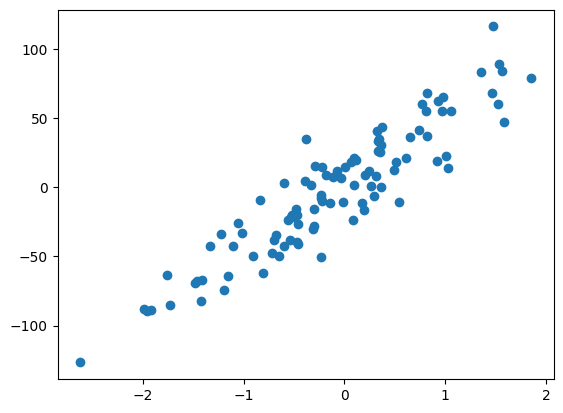

In [2]:
from os import X_OK
x,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=42)

x_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

plt.scatter(x,y)
reg = LinearRegression()
reg.fit(x_train, y_train)
print(reg.coef_)
print(reg.intercept_)

f:\Python\envs\mlenv\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
f:\Python\envs\mlenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
f:\Python\envs\mlenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.167e+04, tolerance: 1.663e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


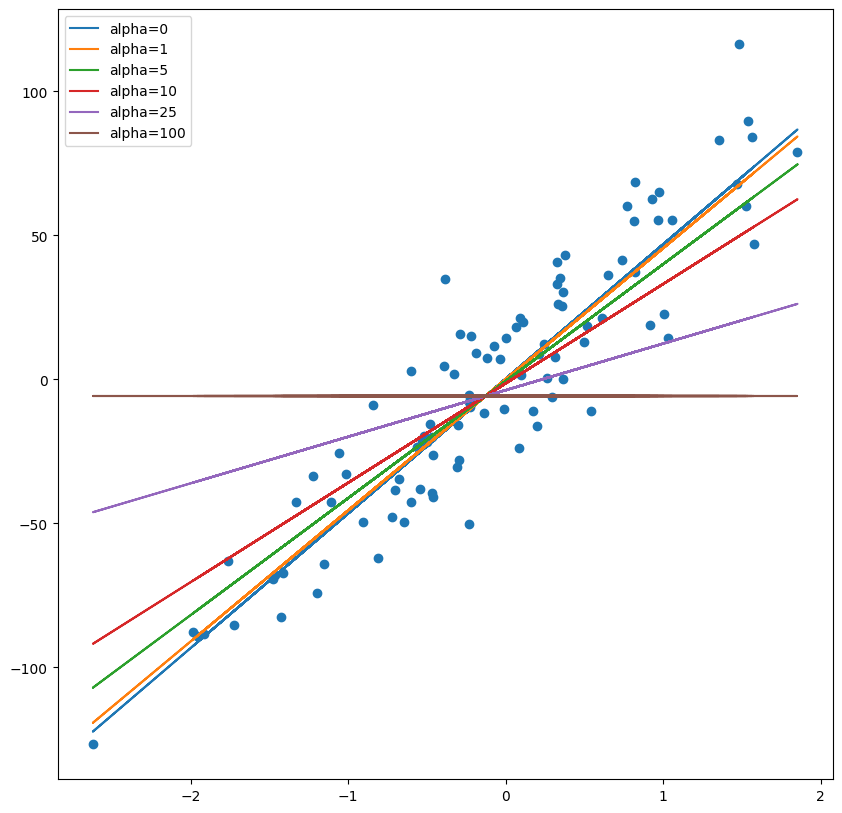

In [3]:
from sklearn.linear_model import Lasso
alpha = [0,1,5,10,25,100]
plt.figure(figsize=(10,10))
plt.scatter(x,y)
for i in alpha:
  L = Lasso(alpha=i)
  L.fit(x_train, y_train)
  plt.plot(x_train, L.predict(x_train), label=f'alpha={i}')
plt.legend()
plt.show()

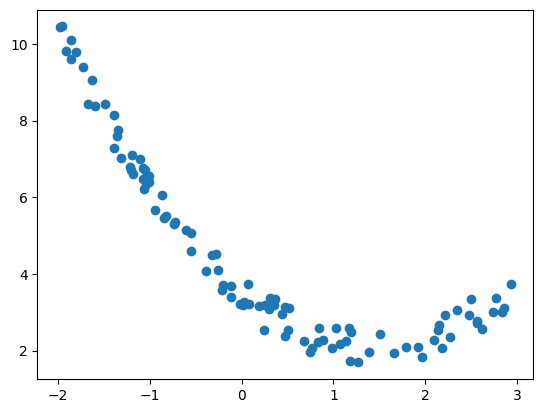

In [4]:
m = 100
x1 = 5*np.random.rand(m,1)-2
x2 = 0.7*x1**2 - 2*x1 + 3 + np.random.rand(m,1)

plt.scatter(x1,x2)

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

f:\Python\envs\mlenv\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
f:\Python\envs\mlenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
f:\Python\envs\mlenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.977e+00, tolerance: 5.872e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
f:\Python\en

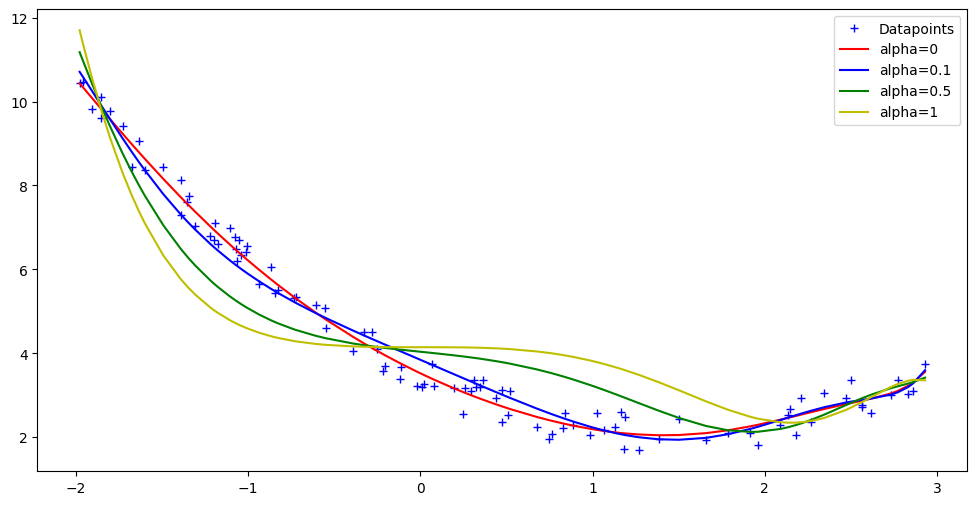

In [6]:
def get_preds_lasso(x1,x2,alpha):
  model = Pipeline([
      ('poly', PolynomialFeatures(degree=16)),
      ('lasso', Lasso(alpha=alpha))
  ])
  model.fit(x1,x2)
  return model.predict(x1)

alpha = [0,0.1,0.5,1]
cs = ['r', 'b', 'g', 'y']

plt.figure(figsize=(12,6))
plt.plot(x1,x2,'b+',label='Datapoints')

for alpha, c in zip(alpha,cs):
  preds = get_preds_lasso(x1,x2,alpha)

  plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0])], c, label=f'alpha={alpha}')
plt.legend()